# 21회차 기출문제 해답

## 문제 1

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn import set_config
import xgboost as xgb
from sklearn.svm import SVR
set_config(display="diagram")
import warnings
warnings.filterwarnings('ignore')

**Data description**

-   school - 학교 유형 (binary: "GP" or "MS")

-   sex - 학생들의 성별 (binary: "F" - female or "M" - male)

-   paid - 과목(Math or Portuguese)에 대한 추가 유료 수업 수강 여부 (binary: yes or no)

-   famrel - 가족관계 (numeric: from 1 - very bad to 5 - excellent)

-   freetime - 방과 후 자유시간 (numeric: from 1 - very low to 5 - very high)

-   goout - 친구들과의 외출 빈도 (numeric: from 1 - very low to 5 - very high)

-   Dalc - 주중 알코올 소비량 (numeric: from 1 - very low to 5 - very high)

-   Walc - 주말 알코올 소비량 (numeric: from 1 - very low to 5 - very high)

-   health - 현재 건강 상태 (numeric: from 1 - very bad to 5 - very good)

-   absences - 결석 횟수 (numeric: from 0 to 93)

-   G3 - 성적 등급 (numeric: from 1 to 11, output target)

In [2]:
dat = pd.read_csv('problem1.csv')
y = dat.grade
X = dat.drop(['grade'], axis = 1)
dat.columns = dat.columns.str.strip().str.lower().str.replace(' ', '_')

In [3]:
pd.options.display.max_columns = None # full 출력 옵션 
dat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   school    366 non-null    object 
 1   sex       366 non-null    object 
 2   paid      366 non-null    object 
 3   famrel    366 non-null    int64  
 4   freetime  366 non-null    int64  
 5   goout     356 non-null    float64
 6   dalc      366 non-null    int64  
 7   walc      366 non-null    int64  
 8   health    366 non-null    int64  
 9   absences  366 non-null    int64  
 10  grade     366 non-null    int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 31.6+ KB


In [4]:
num_columns = dat.select_dtypes('number').columns.tolist()
cat_columns = dat.select_dtypes('object').columns.tolist()

**1. 시각화 및 탐색적 자료분석을 수행하시오.**


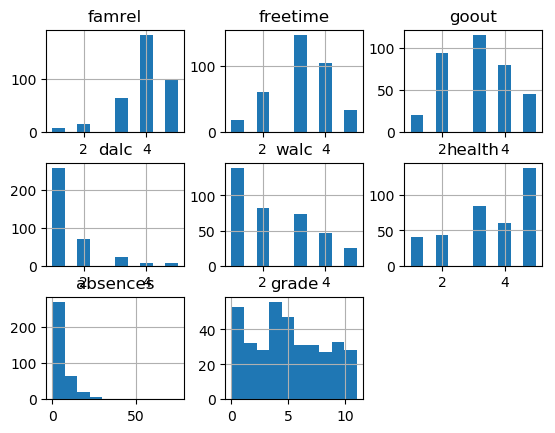

In [5]:
dat.select_dtypes('number').hist();
plt.show();

famrel, freetime, goout, dalc, walc, health 변수는 모두 0\~ 5점이 very low \~ very high인 리커트 척도이다. 따라서 연속형 변수로 판단하고 분석을 진행하겠다.

::: callout-note
리커트 척도는 등간 척도로 볼 수도 있고, 서열 척도로 볼 수도 있습니다.

서열 척도로 볼 경우 평균, 상관계수 등의 통계량은 활용하기 어렵고, 중앙값, spearman 상관계수 등을 활용하는 것이 적절합니다.
:::

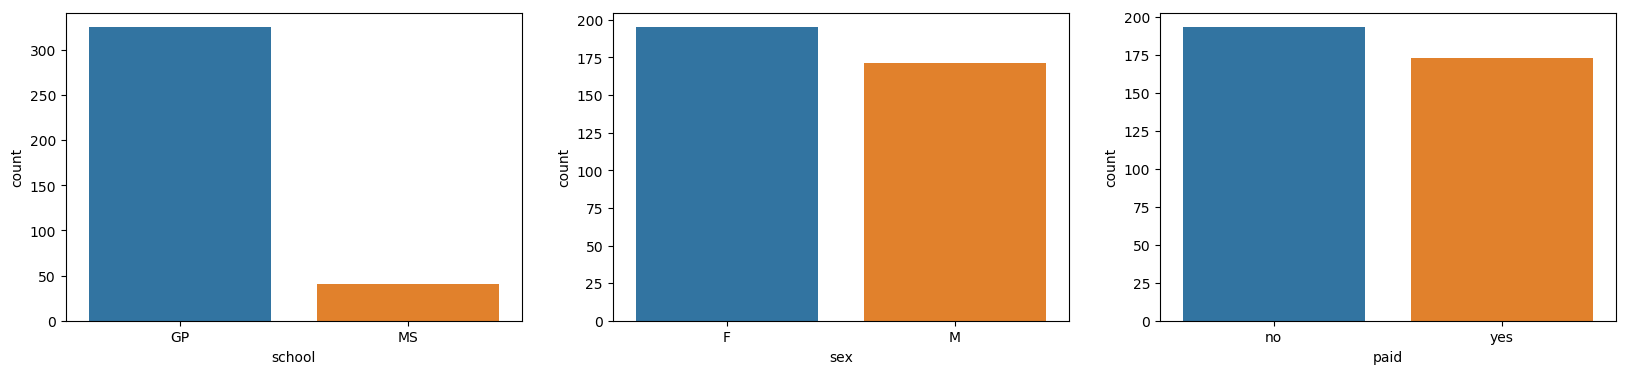

In [6]:
f, axes = plt.subplots(ncols = 3, figsize = (20,4))
sns.countplot(dat['school'], ax = axes[0])
sns.countplot(dat['sex'], ax = axes[1])
sns.countplot(dat['paid'], ax = axes[2])
plt.show();

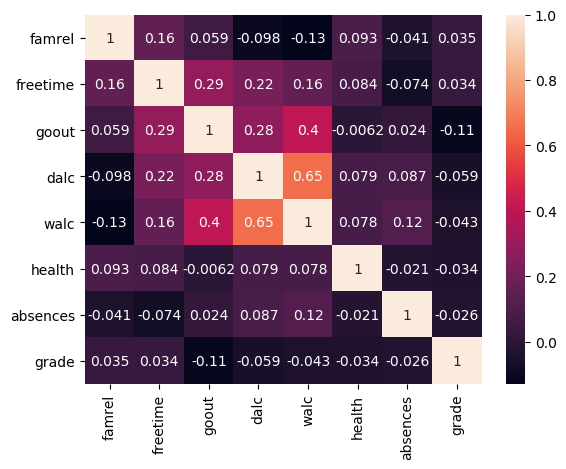

In [7]:
plt.clf() # 초기화 
corr = dat.select_dtypes('number').corr()
sns.heatmap(corr, annot = True)
plt.show();

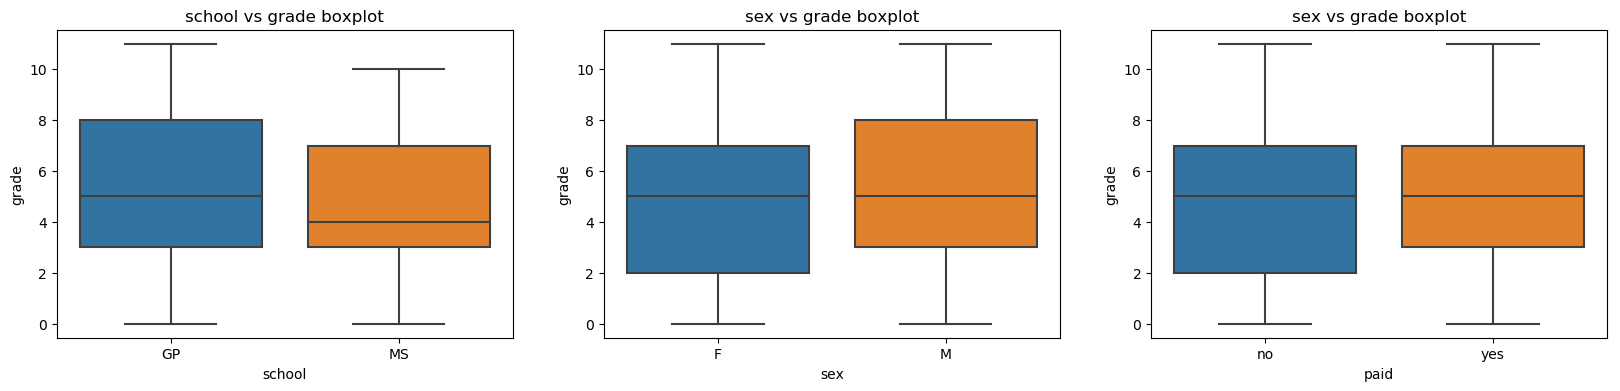

In [8]:
f, axes = plt.subplots(ncols = 3, figsize = (20,4))

sns.boxplot(x = "school", y = "grade", data = dat, ax = axes[0])
axes[0].set_title('school vs grade boxplot')

sns.boxplot(x = "sex", y = "grade", data = dat, ax = axes[1])
axes[1].set_title('sex vs grade boxplot')

sns.boxplot(x = "paid", y = "grade", data = dat, ax = axes[2])
axes[2].set_title('sex vs grade boxplot')

plt.show();

-   goout 변수에 결측치가 존재함

-   school 유형이 GP인 경우 MS인 경우에 비해 8배 이상 많음, 즉, school 변수의 경우 클래스 불균형이 존재함

-   dalc, walc, absences 변수의 분포의 경우 우측으로 긴 꼬리를 갖는 형태를 보임

-   grade와 다른 설명변수 사이에는 상관관계가 낮으며, walc와 dalc, walc와 goout의 경우 다른 변수에 비해서 상대적으로 높은 상관관계를 보임

-   학교 유형에 따른 성적 등급은 큰 차이가 없음

-   성별에 따른 성적 등급을 보면 남성의 경우 여성에 비해 성적 등급이 높은 경향이 있음

-   유료 강의를 수강 여부와 관계없이 남성이 여성에 비해 성적 등급이 높은 경향이 있음

**2. 결측치를 식별 및 결측치 대치를 실시하고, 해당 대치방법을 선택한 이유를 작성하시오(대치 방법 2가지 이상 서술).**

In [9]:
(dat
    .isna()
    .sum(axis = 0) 
)

school       0
sex          0
paid         0
famrel       0
freetime     0
goout       10
dalc         0
walc         0
health       0
absences     0
grade        0
dtype: int64

-   goout에 결측치가 10개 존재함

In [10]:
impute_preprocess = make_pipeline(
    IterativeImputer(estimator = RandomForestRegressor(), max_iter = 5)
)

preprocess = ColumnTransformer(
    [("imputation", impute_preprocess, num_columns)]
)

preprocess

ColumnTransformer(transformers=[('imputation',
                                 Pipeline(steps=[('iterativeimputer',
                                                  IterativeImputer(estimator=RandomForestRegressor(),
                                                                   max_iter=5))]),
                                 ['famrel', 'freetime', 'goout', 'dalc', 'walc',
                                  'health', 'absences', 'grade'])])

In [11]:
impute_dat = preprocess.fit_transform(dat)
np.shape(impute_dat)
num_data = pd.DataFrame(impute_dat, columns = num_columns)
num_data.isna().sum()

famrel      0
freetime    0
goout       0
dalc        0
walc        0
health      0
absences    0
grade       0
dtype: int64

-   Random forest를 이용해서 결측치를 대치함

결측치를 처리하는 방법은 크게 대표값을 이용하는 방법과 모델을 이용하는 방법이 있다.

대표값을 이용한 방법 중 대표적으로 평균대치법이 있다. 평균대치법은 해당 변수의 대표값인 평균으로 결측치를 대치하는 방법으로 단점으로는 결측치 수가 많을 때 분포가 왜곡되는 문제가 있을 수 있다.

모델을 이용한 방법 중 대표적으로 random forest를 이용한 방법이 있다. random forest를 이용한 방법은 boostrap sample에서 변수를 랜덤하게 선택하여 개별 tree를 생성하고, 개별 tree에서 나온 예측값을 평균내서 나온 값을 이용해서 결측치를 대치하는 방법이다.

random forest를 이용해서 결측치를 대치한 이유는 대표값을 이용하는 방법에 비해서 다른 변수의 정보를 이용해서 결측치를 대치할 수 있기 때문에 더 많은 정보를 활용해서 결측치를 대치할 수 있기 때문이다.

**3. 범주형 변수 중 변환이 필요할 경우 변환을 실시하고, 해당 변환을 실시한 이유를 서술하시오(5점).**

In [12]:
encoding_preprocess = make_pipeline(
    OneHotEncoder(handle_unknown="ignore", sparse=False)
)

preprocess = ColumnTransformer(
    [("cat", encoding_preprocess, cat_columns)]
)

preprocess

ColumnTransformer(transformers=[('cat',
                                 Pipeline(steps=[('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse=False))]),
                                 ['school', 'sex', 'paid'])])

In [13]:
encoding_dat = preprocess.fit_transform(dat)
cat_cols = preprocess.named_transformers_["cat"].named_steps["onehotencoder"].get_feature_names(cat_columns)
cat_data = pd.DataFrame(encoding_dat, columns = cat_cols)
cat_data.head(2)

,school_GP,school_MS,sex_F,sex_M,paid_no,paid_yes
0,1.0,0.0,1.0,0.0,1.0,0.0
1,1.0,0.0,1.0,0.0,1.0,0.0


범주형 변수 변환 방법은 크게 3가지가 있다. 첫 번째로, label encoding 방법은 범주형 변수의 각 값에 알파벳 순서대로 정수값을 할당하는 방법이다. 두 번째로, one-hot encoding 방법은 범주형 변수의 각 수준(levels)별로 변수를 생성하며, 생성된 개별 변수는 각 수준에 해당하는 경우 1, 해당하지 않는 경우 0으로 구성된다. 세 번째로, dummy coding의 경우 one-hot encoding과 유사하지만 각 수준(levels) - 1개 만큼 변수를 생성하며, 생성된 개별 변수는 각 수준에 해당하는 경우 1, 해당하지 않는 경우 0으로 구성된다.

이 중 one-hot encoding을 선택한 이유는 label encoding과 비교했을 때, 범주에 수치정보가 반영되는 문제점이 없으며, 범주형 변수의 각 수준(levels)이 크지 않기 때문에 one-hot encoding의 문제점 중 하나인 차원이 늘어남에 따라 계산량이 증가하는 문제 또한 미미하기 때문이다. 또한 앞으로 적합시킬 모델이 glm 계열 모델이 아니기 때문에 one-hot encoding의 문제점 중 하나인 glm 모델일 때 범주형 변수 간의 다중공선성 문제 또한 없기 때문이다.

**4. 적절한 데이터 분할 방법을 실시하고, 해당 분할 방법을 선택한 이유를 작성하시오(데이터 분할 방법론 2가지 서술)(5점).**

In [14]:
pre_dat = pd.concat([cat_data, num_data], axis = 1) # cbind
y = pre_dat.grade
X = pre_dat.drop(['grade'], axis = 1)

In [15]:
bins = np.nanquantile(y, np.arange(0, 1, 0.1))
y_binned = np.digitize(y, bins)

In [16]:
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size = 0.2, stratify = y_binned, random_state = 0)

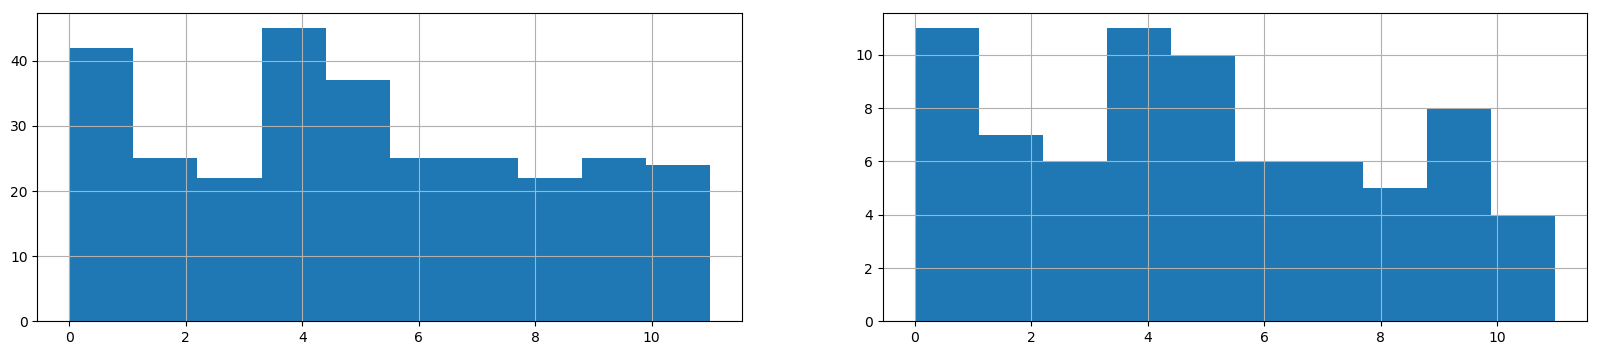

In [17]:
f, axes = plt.subplots(ncols = 2, nrows = 1, figsize = (20,4))
train_y.hist(ax = axes[0]);
test_y.hist(ax = axes[1]);
plt.show()

데이터를 분할하는 방법은 대표적으로 simple random sampling, strata sampling이 있다. 첫 번째로, simple random sampling은 데이터를 무작위로 특정 비율로 분할하는 방법이다. 두 번째로, strata sampling은 class 불균형 문제에 대한 해결 방안으로 지정된 범주형 변수의 각 class에 해당하는 하위 샘플에 별도로 simple random sampling을 통해서 데이터를 분할하고, 이후 결합하는 방식으로 전체 데이터셋을 분할하는 방법이다. strata sampling은 연속형 변수의 경우 quantile을 기준으로 비닝을 함으로써 범주형 변수에서 시행하는 것과 같은 방식으로 진행된다.

grade의 분포의 경우 3\~6의 값이 많기 때문에 quantile을 기준으로 적절한 비닝을 통해 strata sampling을 진행한다면 train/test의 분포를 유사하게 유지할 수 있다고 판단했다. 그래프를 확인해본 결과 train/test의 grade 분포는 유사한 형태를 띄는 것을 확인할 수 있다.

그래프를 통해 확인했지만, grade 변수에 대해서 train/test 분포가 같은지 통계적으로 검정해보고자 한다. 두 분포의 유사성을 검정하는 방법은 k-s test를 활용해볼 수 있다.

In [18]:
from scipy import stats
stats.ks_2samp(train_y, test_y)

KstestResult(statistic=0.02850796001480933, pvalue=0.9999999942427156)

유의수준 5%에서 p-value = 0.99이므로, 귀무가설을 기각할 수 없다. 따라서 grade의 train/test 분포는 통계적으로 동일한 분포라고 볼 수 있다.

In [19]:
import pandas as pd
from scipy import stats

num_col = ['famrel', 'freetime', 'goout', 'dalc', 'walc', 'health', 'absences']

result = pd.DataFrame()

for i in range(len(num_col)):
    sample1 = train_X.loc[:, num_col[i]]
    sample2 = test_X.loc[:, num_col[i]]
    p_value = stats.ks_2samp(sample1, sample2).pvalue
    
    tt = pd.DataFrame({'var_name': [num_col[i]], 'P_value': [p_value]})
    result = pd.concat([result, tt], ignore_index=True)

result


,var_name,P_value
0,famrel,0.867393
1,freetime,0.931428
2,goout,0.912473
3,dalc,0.924247
4,walc,0.999298
5,health,0.999994
6,absences,0.675537


설명변수에 대해서 k-s test를 동일하게 진행해본 결과 유의수준 5%에서 p-value \> 0.05이므로, 귀무가설을 기각할 수 없다. 따라서 train/test 분포는 통계적으로 동일한 분포하고 볼 수 있다.

**5. SVM, XGBOOST, RANDOM FOREST 3개 알고리즘의 공통점에 대해 작성하고, 해당모델이 주어진 데이터에 대한 예측 분석에 적합한 알고리즘인지 설명하시오(10점).**

세 알고리즘은 전부 지도학습 모델이며, 분류와 회귀 문제에 전부 적용될 수 있다. 또한 특정 kernel을 이용한 svm의 경우 xgboost, random forest와 같이 비모수 모델로 간주될 수 있다.

grade를 예측하는 문제를 회귀문제로 고려했을 때 세 알고리즘 모두 회귀 문제에 적용될 수 있기 때문에 적합한 모형이다.

**6. 세 모델을 모두 적합하고, 가장 적합한 모델을 선택하시오(20점).**

::: callout-caution
21회차 기출은 문제 순서가 이미 data leakage 형태이므로, 모델 학습 시에도 validation leakage를 고려할 필요가 없음
:::

In [20]:
cv = KFold(n_splits = 5, shuffle = True, random_state = 0)

In [21]:
RandomForest_param = {'regressor__max_features': np.arange(0.5, 1, 0.1)}
Xgb_param = {'regressor__learning_rate': np.arange(0.01, 0.3, 0.05)}
SVR_param = {'regressor__C': np.arange(1, 100, 20)}

In [22]:
rf_pipe = Pipeline(
    [
        ("regressor", RandomForestRegressor(random_state=42))
    ]
)

xgb_pipe = Pipeline(
    [
        ("regressor", xgb.XGBRegressor())
    ]
)



svm_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("regressor", SVR())
    ]
)

In [23]:
start_time = time.time()
RandomForest_search = GridSearchCV(rf_pipe,
                                   RandomForest_param, 
                                   cv = cv,
                                   scoring = 'neg_root_mean_squared_error'
                                   # scoring={"RMSE": "neg_root_mean_squared_error",
                                   # "MAE" : "neg_mean_absolute_error", 
                                   # "R2": 'r2'}, 
                                   # refit = 'RMSE'
                                   )
                      
RandomForest_search.fit(train_X, train_y)
print("{}s".format(time.time()-start_time))

start_time = time.time()
Xgb_search = GridSearchCV(estimator = xgb_pipe, 
                      param_grid = Xgb_param, 
                      cv = cv,
                      scoring = 'neg_root_mean_squared_error'
                      # scoring={"RMSE": "neg_root_mean_squared_error",
                      #              "MAE" : "neg_mean_absolute_error", 
                      #              "R2": 'r2'}, 
                      #              refit = 'RMSE'
                                   )
Xgb_search.fit(train_X, train_y)
print("{}s".format(time.time()-start_time))

start_time = time.time()
SVR_search = GridSearchCV(estimator = svm_pipe, 
                      param_grid = SVR_param, 
                      cv = cv,
                      scoring = 'neg_root_mean_squared_error'
                      # scoring={"RMSE": "neg_root_mean_squared_error",
                      #              "MAE" : "neg_mean_absolute_error", 
                      #              "R2": 'r2'}, 
                      #              refit = 'RMSE'
                                   )
                                   

SVR_search.fit(train_X, train_y)
print("{}s".format(time.time()-start_time))

2.781989336013794s
[13:46:01] WARNING: C:/Jenkins/workspace/xgboost-win64_release_0.90/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[13:46:01] WARNING: C:/Jenkins/workspace/xgboost-win64_release_0.90/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[13:46:01] WARNING: C:/Jenkins/workspace/xgboost-win64_release_0.90/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[13:46:01] WARNING: C:/Jenkins/workspace/xgboost-win64_release_0.90/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[13:46:01] WARNING: C:/Jenkins/workspace/xgboost-win64_release_0.90/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[13:46:01] WARNING: C:/Jenkins/workspace/xgboost-win64_release_0.90/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederro

In [24]:
# def eval_metrics(eval_cv):
#     eval = (pd.DataFrame(eval_cv.cv_results_)
#         .sort_values('mean_test_RMSE', ascending=False)
#         .head(20)
#         .assign(params = lambda x: x['params'].astype(str))
#     )
#     return eval
# 
# eval_df = eval_metrics(eval_cv= RandomForest_search)
# eval_df

print('Ramdom forest best parameters : ', RandomForest_search.best_params_)
print('Random forest best score : ', -RandomForest_search.best_score_)

print('xgboost best parameters : ', Xgb_search.best_params_)
print('Xgboost best score : ', -Xgb_search.best_score_)

print('SVR best parameters : ', SVR_search.best_params_)
print('SVR best score : ', -SVR_search.best_score_)

Ramdom forest best parameters :  {'regressor__max_features': 0.8999999999999999}
Random forest best score :  3.162173038161167
xgboost best parameters :  {'regressor__learning_rate': 0.060000000000000005}
Xgboost best score :  3.1025233347757166
SVR best parameters :  {'regressor__C': 1}
SVR best score :  3.0241478881710515


교차검증 score를 기준으로 Support vector regression 모형이 가장 우수한 것을 확인할 수 있다.

**7. 선택한 모델의 한계점에 대해 설명하고, 보완할 점이 무엇인지 작성하시오.**

In [25]:
pred = SVR_search.predict(test_X)
from sklearn.metrics import mean_squared_error
mean_squared_error(pred, test_y, squared = False)

2.9674831142128673

최종 검증 데이터에서의 성능은 3.06인 것을 확인할 수 있으며, 교차검증 스코어와 유사한 것을 확인할 수 있다.

Random forest의 경우 변수 중요도, shapley value 등과 같은 방식으로 변수별 중요도를 시각화할 수 있지만 다중회귀모형과 같이 직관적인 해석이 어렵다는 문제가 있다.

이러한 문제를 해결하기 위해서 partial dependence plot과 같이 변수별 영향력을 간접적으로 시각화한다면 해석력을 높일 수 있을 것이다. 또한, 다중회귀모형과 같이 개별 변수의 영향력을 직관적으로 해석할 수 있는 모형을 다시 적합해서 별도의 모델을 구축한다면 해석력을 높일 수 있다.

**8. 현업에서 해당 모델을 사용할 시에 주의할 점에 대해 작성하시오.**

현업에서는 모델의 예측력과 해석력 두 가지가 가장 중요하다. 예측력 관점에서 Random forest 단일 모델의 경우 예측력이 떨어질 수 있다. 따라서 예측력을 높이기 위해서는 Random forest 단일 모형이 아닌 XGBoost, svm, poisson regression 등 다양한 모델을 이용한 앙상블을 통해서 예측력을 높일 수 있을 것이다. 해석력 관점에서 Random forest 모델의 해석력을 높이기 위해서는 위에서 언급한 feature importance plot, shapley value, partial dependence plot 등을 활용한다면 간접적인 해석력을 높일 수 있다.

## 문제 2

**1. 데이터를 8:2로 분할하고, 선형회귀 모델을 적합시키시오(결정계수, RMSE 계산)(5점).**

In [26]:
dat = pd.read_csv('problem2.csv')

In [27]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(dat, test_size=0.2, random_state=123)

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model = LinearRegression()

model.fit(train.drop(columns='medv'), train['medv'])
pred = model.predict(test.drop(columns='medv'))

선형회귀 모델의 RMSE 스코어는 다음과 같다.

In [29]:
rmse = mean_squared_error(test['medv'], pred, squared=False)
print(f'선형 회귀 RMSE: {rmse}')

선형 회귀 RMSE: 5.309659665032156


선형회귀 모델의 결정계수는 다음과 같다.

In [30]:
r2 = r2_score(test['medv'], pred)
print(f'선형 회귀 결정계수 (R^2): {r2}')

선형 회귀 결정계수 (R^2): 0.6592466510354116


**2. 데이터를 8:2로 분할하고, 릿지회귀 모델을 적합시키시오(결정계수, RMSE 계산)(12점).**

-   파라미터 범위는 0\~1까지 0.1단위로 탐색하며, RMSE가 가장 높을 때의 파라미터 값을 찾고, 해당 파라미터의 결정계수와 RMSE를 구하시오.

In [31]:
from sklearn.linear_model import RidgeCV
alphas = [i * 0.1 for i in range(11)]

ridge_model = RidgeCV(alphas=alphas, scoring='neg_mean_squared_error', cv=5)
ridge_model.fit(train.drop(columns='medv'), train['medv'])

ridge_pred = ridge_model.predict(test.drop(columns='medv'))

릿지회귀 모델의 RMSE 스코어는 다음과 같다.

In [32]:
ridge_rmse = mean_squared_error(test['medv'], ridge_pred, squared=False)
print(f'Ridge Regression RMSE: {ridge_rmse}')

Ridge Regression RMSE: 5.319436735308024


릿지회귀 모델의 결정계수는 다음과 같다.

In [33]:
ridge_r2 = r2_score(test['medv'], ridge_pred)

print(f'Ridge Regression R2: {ridge_r2}')

Ridge Regression R2: 0.657990586811741


**3. 데이터를 8:2로 분할하고, 라쏘회귀 모델을 적합시키시오(결정계수, RMSE 계산)(12점).**

-   파라미터 범위는 0\~1까지 0.1단위로 탐색하며, RMSE가 가장 높을 때의 파라미터 값을 찾고, 해당 파라미터의 결정계수와 RMSE를 구하시오.

In [34]:
from sklearn.linear_model import LassoCV
alphas = [i * 0.1 for i in range(11)]

lasso_model = LassoCV(alphas=alphas, cv=5, random_state=123)
lasso_model.fit(train.drop(columns='medv'), train['medv'])
lasso_pred = lasso_model.predict(test.drop(columns='medv'))

라쏘회귀 모델의 RMSE 스코어는 다음과 같다.

In [35]:
lasso_rmse = mean_squared_error(test['medv'], lasso_pred, squared=False)
print(f'Lasso Regression RMSE: {lasso_rmse}')

Lasso Regression RMSE: 5.309659665032175


라쏘회귀 모델의 결정계수는 다음과 같다.

In [36]:
lasso_r2 = r2_score(test['medv'], lasso_pred)
print(f'Lasso Regression R2: {lasso_r2}')

Lasso Regression R2: 0.6592466510354091


## 문제 3

주어진 데이터를 이용해서 아래에 해당하는 그림을 그리시오(12점).

In [37]:
dat = pd.read_csv('problem3.csv')

![](images/clipboard-3862750760.png)

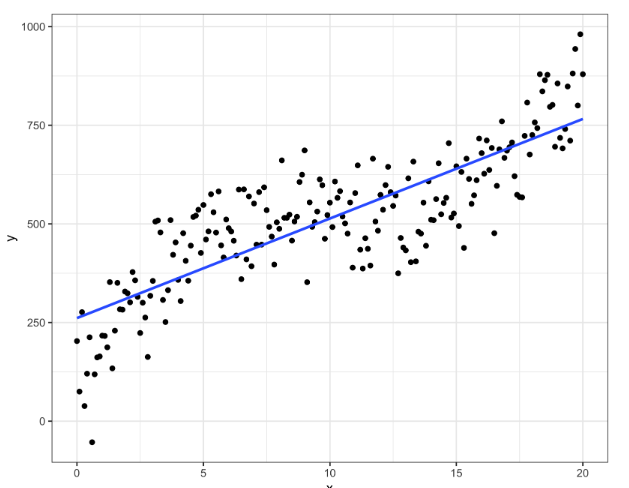

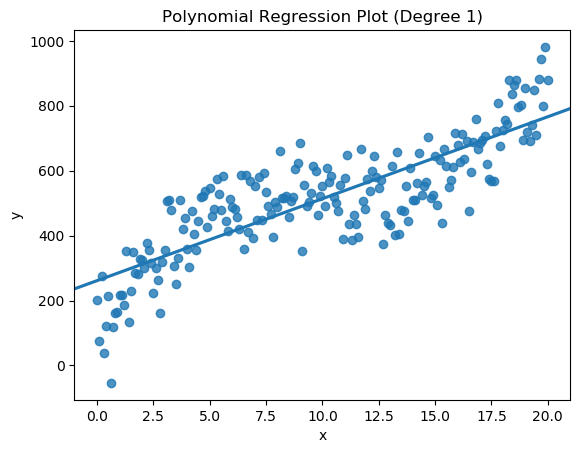

In [38]:
sns.regplot(x='x', y='y', data=dat, order=1, ci=None);
plt.title('Polynomial Regression Plot (Degree 1)');
plt.show();

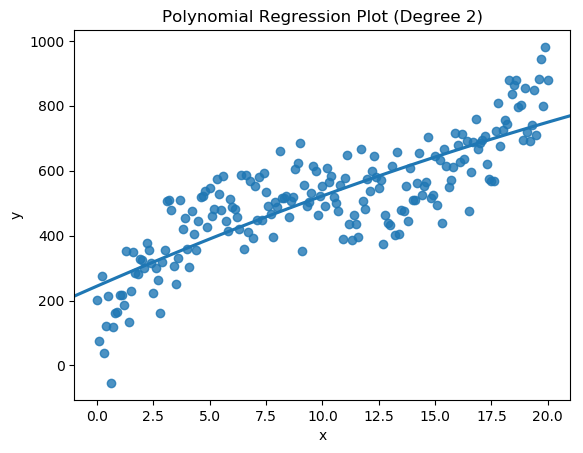

In [39]:
sns.regplot(x='x', y='y', data=dat, order=2, ci=None);
plt.title('Polynomial Regression Plot (Degree 2)');
plt.show();

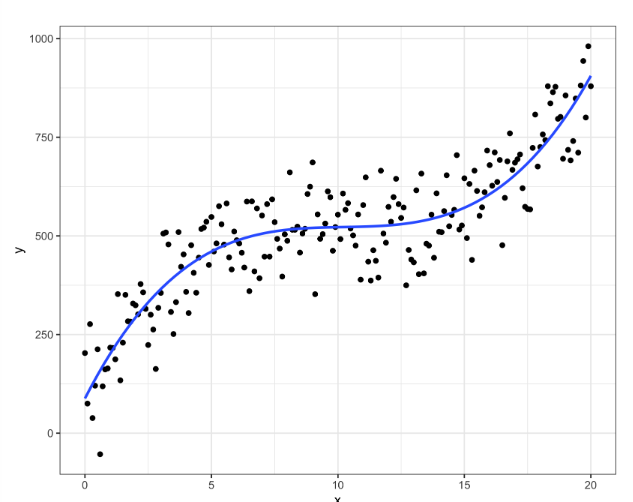

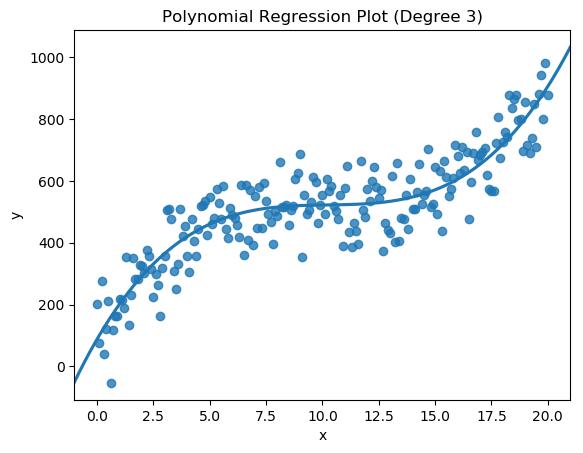

In [40]:
sns.regplot(x='x', y='y', data=dat, order=3, ci=None);
plt.title('Polynomial Regression Plot (Degree 3)');
plt.show();

## 문제 4

**Data description**

-   len : 기니피그의 치아길이
-   dose : 비타민 C 투여량
-   sup : orange juice(OJ), ascorbic acid(VC)

다음의 데이터를 사용하여 기니피그의 치아 길이의 성장이 비타민 투여량과 투약 방법에 따라 차이가 있는지 이원배치 분산분석을 수행하시오.

In [41]:
dat = pd.read_csv('problem4.csv')

-   귀무가설 : 비타민 C 투여량에 따른 기니피그의 평균 치아 성장 차이는 존재하지 않는다.
-   귀무가설 : 비타민 C 투약 방법에 따른 기니피그의 평균 치아 성장 차이는 존재하지 않는다.
-   귀무가설 : 비타민 C 투약 방법과 비타민 C 투여량 사이에는 상호작용 효과가 존재하지 않는다.


In [42]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('len ~ C(supp) * C(dose)', data=dat).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

**정규성 확인**

-   귀무가설 : 데이터는 정규분포를 따른다.

-   대립가설 : 데이터는 정규분포를 따르지 않는다.

In [43]:
from scipy.stats import shapiro

# 잔차의 정규성 검정
shapiro_test = shapiro(model.resid)
print(f'Shapiro-Wilk Test for Normality: p-value = {shapiro_test.pvalue}')

Shapiro-Wilk Test for Normality: p-value = 0.6694232821464539


유의수준 5%에서 p-value = 0.6694로 매우 크므로, 귀무가설을 기각할 수 없다. 따라서 잔차의 정규성을 만족한다.

**등분산성 확인**

-   귀무가설 : 집단 간 분산이 동일하다.

-   대립가설 : 집단 간 분산이 동일하지 않다.

In [44]:
from scipy.stats import levene

grouped_data = [group['len'].values for name, group in dat.groupby(['supp', 'dose'])]
levene_test = levene(*grouped_data)

print(f'Levene’s Test for Homogeneity of Variances: p-value = {levene_test.pvalue}')

Levene’s Test for Homogeneity of Variances: p-value = 0.14836058592870574


유의수준 5%에서 p-value = 0.1484로 매우 크므로, 귀무가설을 기각할 수 없다. 따라서 잔차의 등분산성을 만족한다.

**모델 해석**

In [45]:
print(anova_table)

                      sum_sq    df          F        PR(>F)
C(supp)           205.350000   1.0  15.571979  2.311828e-04
C(dose)          2426.434333   2.0  91.999965  4.046291e-18
C(supp):C(dose)   108.319000   2.0   4.106991  2.186027e-02
Residual          712.106000  54.0        NaN           NaN


-   유의수준 5%에서 supp의 p‑value = 0.000231로 매우 작기 때문에 귀무가설을 기각한다. 따라서 비타민 C 투약방법에 따른 기니피그의 평균 치아 성장에 유의미한 차이가 존재한다.

-   유의수준 5%에서 dose의 p‑value = 4.046291e-18로 매우 작기 때문에 귀무가설을 기각한다. 따라서 비타민 C 투여량에 따른 기니피그의 치아 성장 사이에는 유의미한 차이가 존재한다.

-   유의수준 5%에서 supp:dose의 p‑value = 0.02186으로 매우 작기 때문에 귀무가설을 기각한다. 따라서 비타민 C 투여량과 비타민 C 투약 방법 사이에는 상호작용 효과가 존재한다.